In [2]:
import cv2
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

In [3]:
def imgProcessing(raw_images):
    
    processed_imgs = []
    listaaux=[]
    
    for raw in raw_images:
        thred = cv2.adaptiveThreshold(raw, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
        thred_inv = 255 - thred
        
        contours, _ = cv2.findContours(thred_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for cont in contours:
            x, y, w, h = cv2.boundingRect(cont)
            #cv2.rectangle(thred, (x, y), (x + w, y + h), (0, 255, 0), 1)
        
        rec_resize = cv2.resize(thred_inv[y:y+h+2, x:x+w+2], (25, 25))
        listaaux.append(rec_resize)
        processed_imgs.append(np.array(rec_resize).reshape(-1) / 255.0)
        
        
    final_array = np.array(processed_imgs)
    print(len(final_array))
    print("proc ",len(processed_imgs[0]))
        
    return final_array, listaaux

In [4]:
character_classes = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
n_classes = len(character_classes)
classes_dict = {}

i = 0

for char in character_classes:
    classes_dict.setdefault(char, i)
    i+=1
    
print(classes_dict["V"])
print(len(character_classes))

31
62


In [5]:
charr = 'Z'
print(charr.isalpha())

True


In [6]:
#cargamos imágenes LETRAS
import os

train_directory = "../proyect/images/train_ocr_origen/"

train_images = []
img_classes = []

for character_class in character_classes:
    if(character_class.isdecimal()):
        class_directory = os.path.join(train_directory, character_class)
    elif(character_class.isalpha()):
        if(character_class.isupper()):
            subdir = "mayus"
        else:
            subdir = "minus"
        class_directory = os.path.join(train_directory, subdir, character_class)

    for filename in os.listdir(class_directory):
        image_path = os.path.join(class_directory, filename)
        image = cv2.imread(image_path)
        assert image is not None, "file could not be read, check with os.path.exists()"
        
        train_images.append(cv2.cvtColor(image,cv2.COLOR_BGR2GRAY))
        img_classes.append(classes_dict[character_class])

y_train = np.array(img_classes)
x_train, recortes = imgProcessing(train_images)

print(y_train)
#print(x_train[30000])


38750
proc  625
[ 0  0  0 ... 61 61 61]


38750
38750


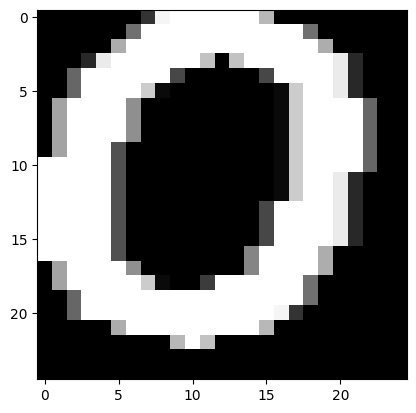

In [7]:
print(len(recortes))
print(len(x_train))
plt.imshow(recortes[0], cmap="gray")
plt.show()

In [8]:
test_directory = "../proyect/images/validation_ocr/"

test_images = []
test_classes = []

for character_class in character_classes:
    if(character_class.isdecimal()):
        class_directory = os.path.join(train_directory, character_class)
    elif(character_class.isalpha()):
        if(character_class.isupper()):
            subdir = "mayus"
        else:
            subdir = "minus"
        class_directory = os.path.join(train_directory, subdir, character_class)

    for filename in os.listdir(class_directory):
        image_path = os.path.join(class_directory, filename)
        image = cv2.imread(image_path)
        assert image is not None, "file could not be read, check with os.path.exists()"
        
        test_images.append(cv2.cvtColor(image,cv2.COLOR_BGR2GRAY))
        test_classes.append(classes_dict[character_class])

y_test = np.array(test_classes)
x_test, recortes_test = imgProcessing(test_images)

print(y_test)

38750
proc  625
[ 0  0  0 ... 61 61 61]


38750
38750
0


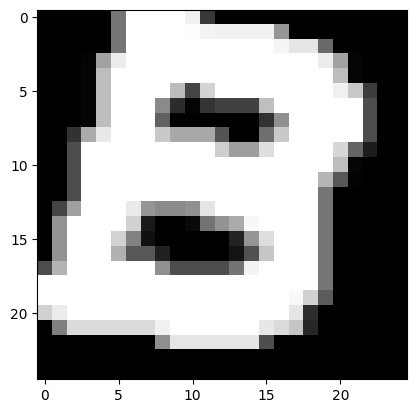

In [9]:
print(len(recortes_test))
print(len(x_test))
print(len(recortes_test) % 250)
plt.imshow(recortes_test[6875], cmap="gray")
plt.show()

In [10]:
print(x_train.shape)
print(len(character_classes*625))
print(len(y_train))
print(y_train.shape)

(38750, 625)
38750
38750
(38750,)


In [11]:
print(x_test.shape)
print(len(y_test))

(38750, 625)
38750


In [12]:
#ENTRENAMIENTO Y EVALUACIÓN MULTICLASE
#from sklearn.model_selection import train_test_split
#x,_,y,_=train_test_split(x_train,y_train,test_size=0.8)
#print(len(x)/len(x_train))
#print(x.shape)
#print(np.unique(y))
#print(np.bincount(y))
#print(np.bincount(y)/len(y))

<h3>LDA + KNN</h3>

<h4>LDA</h4>

In [13]:
print(x_train.shape)
print(y_train.shape)

(38750, 625)
(38750,)


In [14]:
print(y_train[22000])

35


In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
#Entrenamos
lda.fit(x_train,y_train)

#Proyectar
Z = lda.transform(x_train)
print(Z.shape)

(38750, 61)


In [16]:
print(lda.score(x_train,y_train))
ypred = lda.predict(x_train)
print(ypred)

0.9397677419354838
[ 0 24  0 ... 61 18 61]


In [17]:
print(lda.score(x_test,y_test))
y_test_predict = lda.predict(x_test)
print(len(y_test_predict))

z_test = lda.transform(x_test)


0.9397677419354838
38750


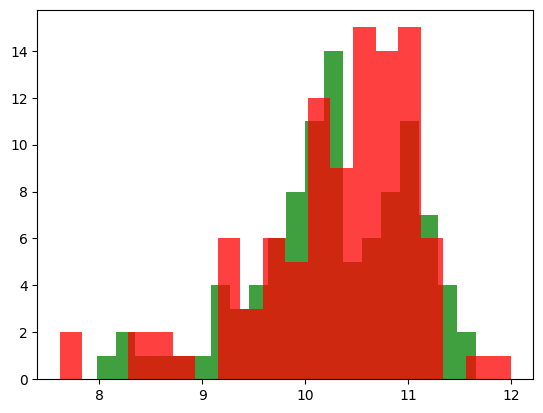

In [18]:
plt.hist(Z[0:100,0], 20,
facecolor='green', alpha=0.75)
plt.hist(Z[100:200,0], 20,
facecolor='red', alpha=0.75)
plt.show()

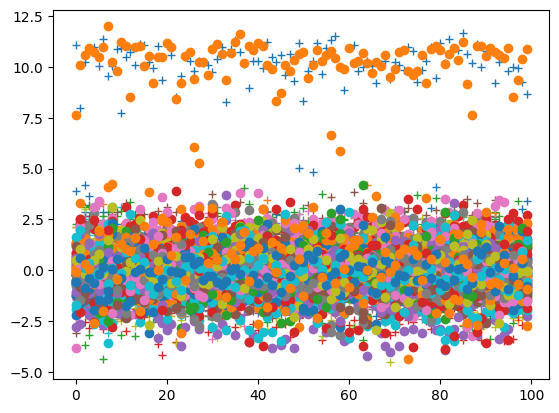

In [19]:
XT = lda.transform(x_train)
plt.plot(XT[0:100],'+')
plt.plot(XT[100:200],'o')
plt.show()

In [20]:
from sklearn.neighbors import KNeighborsClassifier

#Elegimos numero de vecinos
n_neighbors=3

#Creamos Clasificador
knn = KNeighborsClassifier(n_neighbors)
knn.fit(Z,y_train)

print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(Z, y_train)))

print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(z_test, y_test)))

Accuracy of K-NN classifier on training set: 0.97
Accuracy of K-NN classifier on test set: 0.97


In [21]:
from sklearn import metrics

#Predicciones del conjunto de test
pred_knn=knn.predict(z_test)
pred_proba=knn.predict_proba(z_test)
#Métricas del clasificador

print("ACCURACY:", metrics.accuracy_score(y_test,pred_knn))
print("PRECISION: ", metrics.precision_score(y_test,pred_knn,average='weighted'))
print("RECALL: ", metrics.recall_score(y_test,pred_knn,average='weighted'))
print("F1-SCORE: ",metrics.f1_score(y_test,pred_knn,average='weighted'))

#Alternativa
print(metrics.classification_report(y_test,pred_knn))



ACCURACY: 0.9684387096774194
PRECISION:  0.9706625909844695
RECALL:  0.9684387096774194
F1-SCORE:  0.9654657464225986
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       625
           1       0.98      0.99      0.98       625
           2       1.00      1.00      1.00       625
           3       1.00      1.00      1.00       625
           4       1.00      1.00      1.00       625
           5       1.00      1.00      1.00       625
           6       1.00      1.00      1.00       625
           7       1.00      1.00      1.00       625
           8       1.00      1.00      1.00       625
           9       1.00      1.00      1.00       625
          10       1.00      1.00      1.00       625
          11       1.00      1.00      1.00       625
          12       1.00      1.00      1.00       625
          13       1.00      1.00      1.00       625
          14       0.90      1.00      0.94       625
          15     

In [22]:
cm = np.round(metrics.confusion_matrix(y_test, pred_knn, normalize='all'),3)
cmd = metrics.ConfusionMatrixDisplay(cm, display_labels=character_classes)
#plt.figure().set_figwidth(18)
#cmd.plot()
#plt.show()

print("AUC", metrics.roc_auc_score(y_test,pred_proba,multi_class='ovr'))

AUC 0.9924251045161292


<h3>LDA + Gaussiano Naïve</h3>

<h4>Entrenamiento Gaussiano Naïve</h4>

In [23]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(Z, y_train)

zgnb_predict = gnb.predict(z_test)
zgnb_prob_predict = gnb.predict_proba(z_test)

In [24]:
print("Accuracy z_test: ", gnb.score(z_test, y_test))
print("Accuracy z_test prob: ", metrics.accuracy_score(y_test, zgnb_predict))

Accuracy z_test:  0.9449548387096774
Accuracy z_test prob:  0.9449548387096774


In [25]:
print(metrics.roc_auc_score(y_test, zgnb_prob_predict, multi_class='ovr'))

0.9990980978529876


In [26]:
#Precision, recall, f1-score por clase
print(metrics.classification_report(y_test, zgnb_predict))

              precision    recall  f1-score   support

           0       0.61      0.68      0.65       625
           1       0.96      0.88      0.92       625
           2       1.00      1.00      1.00       625
           3       1.00      1.00      1.00       625
           4       1.00      1.00      1.00       625
           5       1.00      1.00      1.00       625
           6       1.00      1.00      1.00       625
           7       0.99      1.00      0.99       625
           8       1.00      1.00      1.00       625
           9       1.00      1.00      1.00       625
          10       1.00      1.00      1.00       625
          11       1.00      1.00      1.00       625
          12       0.98      0.98      0.98       625
          13       1.00      1.00      1.00       625
          14       1.00      0.99      0.99       625
          15       1.00      0.99      1.00       625
          16       1.00      1.00      1.00       625
          17       0.99    

<h3>PCA + KNN<h/h3>

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=200)
pca.fit(x_train)
z_pca = pca.transform(x_train)

In [28]:
print("Autovalores")
print("***********")
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print("Autovectores")
print("***********")
print(pca.components_)

Autovalores
***********
[12.78081737  9.03426028  7.00997774  6.34660118  5.11345464  4.11922117
  3.93624396  3.52679252  3.24266431  2.82134842  2.2482626   1.91655947
  1.71681455  1.61742202  1.55244789  1.33779582  1.23613045  1.04250529
  1.01805569  0.91159346  0.8401333   0.7558693   0.7270913   0.65996916
  0.54591244  0.54349386  0.50840033  0.4814798   0.46297123  0.43070083
  0.40444363  0.38175323  0.35395639  0.33690999  0.32671053  0.30013786
  0.2868055   0.27803912  0.2632039   0.24267011  0.23883111  0.23082084
  0.22529558  0.20841683  0.20473655  0.19526136  0.19187492  0.18658766
  0.17280269  0.16935285  0.16916178  0.16076557  0.15874877  0.14969173
  0.14566001  0.14236008  0.13630826  0.13521038  0.12838086  0.12337987
  0.12006903  0.11611757  0.113907    0.11200849  0.1086577   0.10522076
  0.10246407  0.09833235  0.09703152  0.09443483  0.09356582  0.09092891
  0.08798796  0.08715734  0.08585953  0.08498152  0.08106431  0.08032416
  0.07940582  0.07804854  0

In [29]:
#Varianza en los primeros 50 elementos
result = np.sum(pca.explained_variance_ratio_[:50])
print(result)

0.9002443445611926


In [30]:
#pca.fit(x_test, y_test)

z_pca_test = pca.transform(x_test)

In [31]:
knn2 = KNeighborsClassifier(n_neighbors)
knn.fit(z_pca, y_train)

print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(z_pca, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(z_pca_test, y_test)))

Accuracy of K-NN classifier on training set: 0.97
Accuracy of K-NN classifier on test set: 0.97


In [32]:
#Predicciones del conjunto de test
pred_knn2=knn.predict(z_pca_test)
pred_proba2=knn.predict_proba(z_pca_test)
#Métricas del clasificador

print("ACCURACY:", metrics.accuracy_score(y_test,pred_knn2))
print("PRECISION: ", metrics.precision_score(y_test,pred_knn2,average='weighted'))
print("RECALL: ", metrics.recall_score(y_test,pred_knn2,average='weighted'))
print("F1-SCORE: ",metrics.f1_score(y_test,pred_knn2,average='weighted'))

ACCURACY: 0.969083870967742
PRECISION:  0.9715339917508203
RECALL:  0.969083870967742
F1-SCORE:  0.9660861019944259


In [33]:
#Alternativa
print(metrics.classification_report(y_test,pred_knn2))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       625
           1       0.98      0.98      0.98       625
           2       1.00      1.00      1.00       625
           3       1.00      1.00      1.00       625
           4       1.00      1.00      1.00       625
           5       1.00      1.00      1.00       625
           6       1.00      1.00      1.00       625
           7       1.00      1.00      1.00       625
           8       1.00      1.00      1.00       625
           9       1.00      1.00      1.00       625
          10       1.00      1.00      1.00       625
          11       1.00      1.00      1.00       625
          12       1.00      1.00      1.00       625
          13       1.00      1.00      1.00       625
          14       0.89      1.00      0.94       625
          15       1.00      1.00      1.00       625
          16       1.00      1.00      1.00       625
          17       0.99    

<h3>PCA + Gaussian Naïve</h3>

In [34]:
gnb2 = GaussianNB()
gnb2.fit(z_pca, y_train)

zgnb_predict2 = gnb2.predict(z_pca_test)
zgnb_pred_prob2 = gnb2.predict_proba(z_pca_test)


In [35]:
print(zgnb_predict2.shape)
print(zgnb_pred_prob2.shape)

(38750,)
(38750, 62)


In [36]:
print("Accuracy",gnb2.score(z_pca_test,y_test))
print("Accuracy",metrics.accuracy_score(y_test, zgnb_predict2))

Accuracy 0.9297548387096775
Accuracy 0.9297548387096775


In [37]:
#AUC
print(metrics.roc_auc_score(y_test, zgnb_pred_prob2, multi_class='ovr'))

0.9971511393336857


In [38]:
#Precision, recall, f1-socre por clase
print(metrics.classification_report(y_test, zgnb_predict2))

              precision    recall  f1-score   support

           0       0.60      0.56      0.57       625
           1       0.89      0.85      0.87       625
           2       1.00      0.99      1.00       625
           3       1.00      0.99      1.00       625
           4       1.00      1.00      1.00       625
           5       1.00      1.00      1.00       625
           6       1.00      0.99      1.00       625
           7       0.98      0.99      0.98       625
           8       1.00      1.00      1.00       625
           9       1.00      1.00      1.00       625
          10       1.00      1.00      1.00       625
          11       0.99      1.00      1.00       625
          12       0.96      0.97      0.96       625
          13       0.98      1.00      0.99       625
          14       0.99      0.99      0.99       625
          15       0.99      0.99      0.99       625
          16       1.00      1.00      1.00       625
          17       0.98    

In [39]:
#cargamos imágenes PANELES

panels_directory = "../proyect/images/test_ocr_panels"

panels = []

for filename in os.listdir(panels_directory):
    if filename[len(filename) - 1] != 't':
        filepath = os.path.join(panels_directory, filename)
        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        panels.append(image)
    else:
        print(filename)

gt.txt


In [40]:
#FUNCION custom de umbralización: *PARA PANELES* con MSER y filtrando por aspect ratio
def customThreshold(images):
    thr_imgs = []
    mserletters = cv2.MSER_create(5, 60, 450, 0.25, 0.2, 200)
    for img in images:
        thimg = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
            #contours, _ = cv2.findContours(thimg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            
        regions, _ = mserletters.detectRegions(thimg)
        filtered_regions = []
        #print(len(contours))
        for rg in regions:
            x, y, w, h = cv2.boundingRect(rg)
            if (w) > (h):
                if w < 3 * h:
                    if rg is not None:
                        filtered_regions.append(rg)
        thr_imgs.append(thimg)

    return thr_imgs, filtered_regions

74


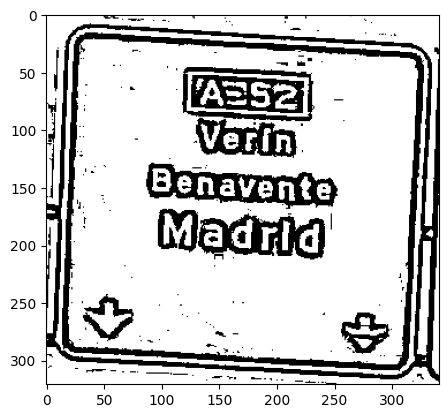

In [41]:
#train_images_threshold = customThreshold(panels)

print(len(panels))

threshold_panels, pan_regions = customThreshold(panels)

plt.imshow(threshold_panels[1], cmap="gray")
plt.show()